# Central Bessel Lobe Analysis — aug6 2× telescope relay (image side)

Same analysis as `axicon3_central_bessel_lobe_2026_08_05.ipynb`, on the `aug6_telescope_*` scans:
the camera looks through a 2× magnification telescope that images the Bessel region of the beam
measured directly in `aug6_axicon3_*` (see `telescope_vs_axicon3_comparison_2026_08_06.ipynb`).
All axes here are IMAGE-SIDE: y is cm after the f_200mm reference, transverse µm are on-sensor.
With transverse magnification M = 2 the ideal core is 2× wider, so the crop/pool/fit windows are
scaled ×2 (±994 µm crop at 13.8 µm/px thumbnails, ±900 µm fit window) and fitted k is compared
against ideal k_r3 / M. Core location uses the matched-filter `find_core` from
`axicon3_central_bessel_lobe_2026_08_06` (windows scaled ×2; raw argmax picks halo speckle);
saturated core frames are cached with sat=True, shown flagged in v1 and dropped from v2 + fits.
No QDHT overlay: the model lives in object space and the image↔object conjugate mapping is not
recorded, so the model cells are omitted in this notebook.

Snapshot through 21-06-22 (aug6_telescope_007 started at 21:22); placements 002/004 were not
scanned — image-side gaps y = 17–25 and 37–45. 21-06-22 stopped during its last slice (y=56).
The caches are incremental — rerun the list + thumbnail cells to pull in later runs.

| run | placement | anchor y (mm) | slices | beam y (cm) |
|---|---|---|---|---|
| 18-38-37 | aug6_telescope_001 | 50 | 13 | 5–17 |
| 20-57-25 | aug6_telescope_003 | 250 | 13 | 25–37 |
| 21-06-22 | aug6_telescope_005 | 450 | 12+ | 45–56 — stopped mid-slice at y=56 |

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent

RUNS = ["auto_scan-2026-08-06_18-38-37",   # ascending image-side y
        "auto_scan-2026-08-06_20-57-25",
        "auto_scan-2026-08-06_21-06-22"]
RUN_DIRS = {r: REPO / "profiler/data" / r for r in RUNS}

PX_UM = 3.45                       # native camera pixel (µm)
FRAME_SHAPE = (1536, 2048)         # raw frame (rows, cols)
M_TEL = 2.0                        # telescope transverse magnification
D_IN_MM = 9.30                     # 1/e² input diameter after telescope (recorded GaussianBeamWaist_mm = 4.65)
ALPHA3_DEG = 0.5
THETA3_MRAD = 4.00                 # deflection after axicon 3 (object side)

# Every figure is also written out as images/<notebook filename>/<description>.png.
OPTIC_TITLE = ("axicon1,2 alpha = 5.0deg, axicon3 alpha = 0.5deg, "
               "L$_{12}$ separation = 175.0mm, L$_{23}$ separation = 415.0mm, "
               "2x telescope (image side, y after f_200mm)")

NOTEBOOK_STEM = "telescope_central_bessel_lobe_2026_08_06"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
# --- core-frame list: raw frames containing the central Bessel lobe ----------
# Selection (manifest-only, no image files opened):
#   1. every aug6 auto_scan run dir with a frames.jsonl whose
#      auto_scan_setup.json PlacementID starts with "aug6_telescope" — the
#      aug6_axicon3_* runs share the date glob and are filtered out here;
#      a truncated trailing line (run still writing) is skipped with a warning
#   2. keep ScanKind == "AutoBeamStack", drop '-dark' relabeled proof frames
#   3. per slice, per-frame peak rate = Max / Exposure_us; a frame is a core
#      CANDIDATE if its rate >= CORE_RATIO_MIN x the slice's best rate.
#      This manifest-only cut is only a cheap PRE-FILTER (0.4, matching the
#      aug6 direct notebook) — the thumbnail cell opens the images and keeps
#      only frames with a validated core
#   4. saturated frames are KEPT and flagged n_sat_px > 0
#   5. writes reductions/telescope_core_frames_2026_08_06.csv
import csv

CORE_RATIO_MIN = 0.4
PLACEMENT_PREFIX = "aug6_telescope"
EXCLUDED = set()          # no junk whole runs identified

core_rows = []
scan_dirs = []
for d in sorted((REPO / "profiler/data").glob("auto_scan-2026-08-06_*")):
    if not (d / "frames.jsonl").exists():
        continue
    try:
        setup = json.loads((d / "auto_scan_setup.json").read_text())
    except (OSError, json.JSONDecodeError) as e:
        print(f"WARNING {d.name}: unreadable auto_scan_setup.json ({e}) — run skipped")
        continue
    if setup.get("PlacementID", "").startswith(PLACEMENT_PREFIX):
        scan_dirs.append(d)
for run_dir in scan_dirs:
    slices = {}
    for ln, line in enumerate(open(run_dir / "frames.jsonl"), start=1):
        if not line.strip():
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"WARNING {run_dir.name} frames.jsonl:{ln} unparseable "
                  f"({e}) — skipped (run still writing?)")
            continue
        ex = rec.get("Extra", {})
        if ex.get("ScanKind") != "AutoBeamStack":
            continue
        if Path(rec["Path"]).stem.endswith("-dark"):
            continue
        slices.setdefault(ex["Subfolder"], []).append(rec)
    for sub, recs in sorted(slices.items()):
        best = max(r["Max"] / r["Extra"]["Exposure_us"] for r in recs)
        for r in recs:
            rate = r["Max"] / r["Extra"]["Exposure_us"]
            if rate < CORE_RATIO_MIN * best:
                continue
            core_rows.append(dict(
                beam_y_cm=r["Extra"]["BeamY_mm"] / 10.0,
                run=run_dir.name, slice=sub, frame=Path(r["Path"]).name,
                gantry_x_mm=r["GantryPosition_mm"]["x_mm"],
                gantry_z_mm=r["GantryPosition_mm"]["z_mm"],
                max_counts=r["Max"],
                exposure_us=round(r["Extra"]["Exposure_us"], 1),
                rate_c_per_us=round(rate, 4),
                ratio_to_slice_best=round(rate / best, 3),
                n_sat_px=r.get("SaturatedPixelCount", 0),
                excluded_run=run_dir.name in EXCLUDED))
core_rows.sort(key=lambda r: (r["beam_y_cm"], r["run"], r["frame"]))
CORE_CSV = Path("reductions/telescope_core_frames_2026_08_06.csv")
with open(CORE_CSV, "w", newline="") as fh:
    wcsv = csv.DictWriter(fh, fieldnames=list(core_rows[0].keys()))
    wcsv.writeheader()
    wcsv.writerows(core_rows)
n_main = sum(not r["excluded_run"] for r in core_rows)
n_sat = sum(r["n_sat_px"] > 0 for r in core_rows)
print(f"{len(core_rows)} core frames -> {CORE_CSV} "
      f"({n_main} from analysis runs, {len(core_rows) - n_main} from excluded "
      f"runs, {n_sat} saturated)")
for run_dir in scan_dirs:
    n = sum(1 for r in core_rows if r["run"] == run_dir.name)
    print(f"  {run_dir.name}: {n}")

93 core frames -> reductions/telescope_core_frames_2026_08_06.csv (93 from analysis runs, 0 from excluded runs, 3 saturated)
  auto_scan-2026-08-06_18-38-37: 50
  auto_scan-2026-08-06_20-57-25: 21
  auto_scan-2026-08-06_21-06-22: 22


In [3]:
# --- core-frame thumbnails, cached (incremental) -----------------------------
# Preprocessing (input list: reductions/telescope_core_frames_2026_08_06.csv):
#   1. keep analysis-run rows only (excluded_run == False). Saturated rows
#      are reduced too and carried with sat=True — v1 shows them flagged,
#      v2 and everything downstream drops them
#   2. CORE FINDER — the matched filter from
#      axicon3_central_bessel_lobe_2026_08_06 with every window scaled x2
#      for the 2x-magnified core (raw argmax picks halo speckle):
#        a. s17 = 17x17 box mean (~core scale; swallows isolated hot pixels)
#        b. cs = s17 - 121x121 box mean — center-minus-surround; candidate
#           = argmax(cs)
#        c. validation: median(s17) on the 50-120 px annulus about the
#           candidate / s17[candidate] <= RING_MED_MAX (0.25, unchanged —
#           the bore/ring contrast is magnification-invariant)
#      halo-only candidates are dropped with a printed note and never
#      cached, so they are re-tested (cheaply) on every rerun
#   3. crop +-288 native px (+-994 um) about the validated core; regions off
#      the sensor stay NaN; 4x4 mean-pool -> 144x144 thumbnails at
#      13.8 um/px, raw counts (same samples-per-fringe as direct)
#   4. the cache is INCREMENTAL: (run, frame) rows missing from the npz are
#      reduced from raw and appended — delete the npz to force a full
#      rebuild. A cache without the 'sat' field (pre-core-finder schema,
#      argmax crops) is discarded and rebuilt automatically
import csv
from scipy.ndimage import uniform_filter

THUMB_CACHE = Path("reductions/telescope_core_thumbs_2026_08_06.npz")
HALF_PX, POOL = 288, 4
CORE_BOX, SURROUND_BOX = 17, 121   # px — 2x the direct-measurement windows
RING_R_PX = (50, 120)              # validation annulus about the candidate
RING_MED_MAX = 0.25


def find_core(a):
    '''Validated core (iy, ix, ring_contrast) in raw frame a, else None.'''
    s_c = uniform_filter(a, CORE_BOX)
    cs = s_c - uniform_filter(a, SURROUND_BOX)
    iy, ix = np.unravel_index(np.argmax(cs), cs.shape)
    yy, xx = np.ogrid[:a.shape[0], :a.shape[1]]
    rr = np.hypot(yy - iy, xx - ix)
    ring = s_c[(rr >= RING_R_PX[0]) & (rr <= RING_R_PX[1])]
    contrast = float(np.median(ring) / s_c[iy, ix])
    return (iy, ix, contrast) if contrast <= RING_MED_MAX else None


rows = [r for r in csv.DictReader(open(CORE_CSV))
        if r["excluded_run"] == "False"]

_d = np.load(THUMB_CACHE, allow_pickle=True) if THUMB_CACHE.exists() else None
if _d is not None and "sat" not in _d.files:
    print(f"{THUMB_CACHE} predates the matched-filter core finder "
          "(argmax crops) — rebuilding from raw")
    _d = None
if _d is not None:
    core_thumbs, ct_ys = _d["thumbs"].astype(np.float32), _d["ys_cm"]
    ct_runs, ct_frames, ct_sat = _d["runs"], _d["frames"], _d["sat"]
    print(f"loaded cached core thumbnails {core_thumbs.shape}")
else:
    core_thumbs = np.zeros((0, 2 * HALF_PX // POOL, 2 * HALF_PX // POOL),
                           np.float32)
    ct_ys = np.zeros(0)
    ct_runs = ct_frames = np.zeros(0, dtype="U8")
    ct_sat = np.zeros(0, bool)

have = set(zip(ct_runs.tolist(), ct_frames.tolist()))
todo = [r for r in rows if (r["run"], r["frame"]) not in have]
n_dropped = 0
if todo:
    thumbs, ys_l, runs_l, frames_l, sat_l = [], [], [], [], []
    for r in todo:
        p = REPO / "profiler/data" / r["run"] / r["slice"] / r["frame"]
        if not p.exists():
            print(f"MISSING raw frame {p} — left out of the gallery")
            n_dropped += 1
            continue
        a = np.load(p).astype(np.float32)
        hit = find_core(a)
        if hit is None:
            n_dropped += 1
            print(f"no validated core in y={float(r['beam_y_cm']):g} "
                  f"x={float(r['gantry_x_mm']):g} z={float(r['gantry_z_mm']):g} "
                  f"({r['frame'][:24]}...) — halo only, dropped")
            continue
        iy, ix, _ = hit
        crop = np.full((2 * HALF_PX, 2 * HALF_PX), np.nan, np.float32)
        y0, y1 = max(iy - HALF_PX, 0), min(iy + HALF_PX, a.shape[0])
        x0, x1 = max(ix - HALF_PX, 0), min(ix + HALF_PX, a.shape[1])
        crop[y0 - (iy - HALF_PX):y0 - (iy - HALF_PX) + (y1 - y0),
             x0 - (ix - HALF_PX):x0 - (ix - HALF_PX) + (x1 - x0)] = a[y0:y1, x0:x1]
        pl = crop.reshape(HALF_PX * 2 // POOL, POOL, -1, POOL).transpose(0, 2, 1, 3)
        thumbs.append(np.nanmean(pl.reshape(pl.shape[0], pl.shape[1], -1), axis=2))
        ys_l.append(float(r["beam_y_cm"])); runs_l.append(r["run"])
        frames_l.append(r["frame"]); sat_l.append(int(r["n_sat_px"]) > 0)
    if thumbs:
        core_thumbs = np.concatenate([core_thumbs,
                                      np.array(thumbs, dtype=np.float32)])
        ct_ys = np.concatenate([ct_ys, np.array(ys_l)])
        ct_runs = np.concatenate([ct_runs.astype(object),
                                  np.array(runs_l, object)])
        ct_frames = np.concatenate([ct_frames.astype(object),
                                    np.array(frames_l, object)])
        ct_sat = np.concatenate([ct_sat, np.array(sat_l, bool)])
        np.savez_compressed(THUMB_CACHE, thumbs=core_thumbs.astype(np.float16),
                            ys_cm=ct_ys, runs=ct_runs.astype(str),
                            frames=ct_frames.astype(str), sat=ct_sat,
                            half_um=993.6, um_per_px=13.8)
        print(f"reduced and appended {len(thumbs)} thumbnails "
              f"-> {core_thumbs.shape[0]} cached")
ct_runs, ct_frames = ct_runs.astype(str), ct_frames.astype(str)
print(f"{core_thumbs.shape[0]} core thumbs ({int(ct_sat.sum())} saturated), "
      f"{n_dropped} halo-only candidates dropped this run")
assert core_thumbs.shape[0] + n_dropped == len(rows), (
    f"cache has {core_thumbs.shape[0]} thumbs + {n_dropped} dropped this run "
    f"but the core list wants {len(rows)} — delete {THUMB_CACHE} to rebuild")

loaded cached core thumbnails (85, 144, 144)


no validated core in y=45 x=50 z=-93.1 (aug6_telescope_005-table...) — halo only, dropped


no validated core in y=45 x=50 z=-97.1 (aug6_telescope_005-table...) — halo only, dropped
no validated core in y=45 x=50 z=-101.1 (aug6_telescope_005-table...) — halo only, dropped


no validated core in y=45 x=55 z=-93.1 (aug6_telescope_005-table...) — halo only, dropped
no validated core in y=45 x=55 z=-97.1 (aug6_telescope_005-table...) — halo only, dropped


no validated core in y=45 x=55 z=-101.1 (aug6_telescope_005-table...) — halo only, dropped
no validated core in y=45 x=60 z=-97.1 (aug6_telescope_005-table...) — halo only, dropped


no validated core in y=45 x=60 z=-101.1 (aug6_telescope_005-table...) — halo only, dropped
85 core thumbs (2 saturated), 8 halo-only candidates dropped this run


saved images/telescope_central_bessel_lobe_2026_08_06/core_frame_gallery_v1.png


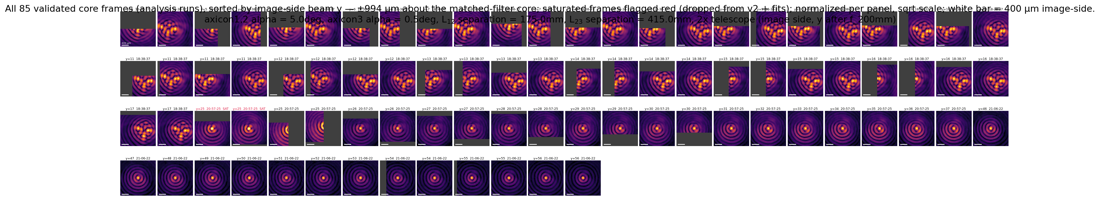

In [4]:
# --- core-frame gallery ------------------------------------------------------
order = np.lexsort((ct_frames, ct_runs, ct_ys))
N_COLS_CF = 24
n_rows_cf = int(np.ceil(len(order) / N_COLS_CF))
cmap_cf = plt.get_cmap("inferno").copy()
cmap_cf.set_bad("0.25")
fig, axes = plt.subplots(n_rows_cf, N_COLS_CF,
                         figsize=(0.95 * N_COLS_CF, 1.08 * n_rows_cf),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, i in zip(np.ravel(axes), order):
    t = core_thumbs[i]
    ax.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
              vmin=0, vmax=1, interpolation="nearest")
    # scale bar: 400 um image-side = 29.0 thumb px (13.8 um/px)
    ax.plot([5, 5 + 400 / 13.8], [137, 137], color="w", lw=1.0,
            solid_capstyle="butt")
    ax.set_title(f"y={ct_ys[i]:g}  {str(ct_runs[i])[-8:]}"
                 + ("  SAT" if ct_sat[i] else ""),
                 color="crimson" if ct_sat[i] else "black",
                 fontsize=4.5, pad=1.5)
fig.subplots_adjust(top=0.98, hspace=0.25, wspace=0.05)
fig.suptitle(f"All {len(order)} validated core frames (analysis runs), "
             "sorted by image-side beam y — ±994 µm about the matched-filter "
             "core; saturated frames flagged red (dropped from v2 + fits); "
             "normalized per panel, sqrt scale; white bar = 400 µm "
             "image-side.\n" + OPTIC_TITLE,
             y=0.999, fontsize=13)
for ax in np.ravel(axes)[:1]:
    ax.text(5, 133, "400 µm", color="w", fontsize=3.5, va="bottom")
save_fig("core_frame_gallery_v1")
plt.close(fig)
# inline preview only — the full-res png is large
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_frame_gallery_v1.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

y=25: backfilled with edge-clipped aug6_telescope_003-tableyp000250.000mm-gantryxp000060.000mm-yp000130.000mm-zm000102.100mm-shot0000.npy (45% on-sensor)
y=26: backfilled with edge-clipped aug6_telescope_003-tableyp000260.000mm-gantryxp000055.000mm-yp000120.000mm-zm000102.100mm-shot0000.npy (88% on-sensor)
y=27: backfilled with edge-clipped aug6_telescope_003-tableyp000270.000mm-gantryxp000055.000mm-yp000110.000mm-zm000098.100mm-shot0000.npy (85% on-sensor)
y=28: backfilled with edge-clipped aug6_telescope_003-tableyp000280.000mm-gantryxp000055.000mm-yp000100.000mm-zm000098.100mm-shot0000.npy (91% on-sensor)
y=29: backfilled with edge-clipped aug6_telescope_003-tableyp000290.000mm-gantryxp000055.000mm-yp000090.000mm-zm000098.100mm-shot0000.npy (98% on-sensor)
v2: 39 frames = 34 filled - 0 saturated - 0 excluded + 5 backfilled


saved images/telescope_central_bessel_lobe_2026_08_06/core_frame_gallery_v2.png


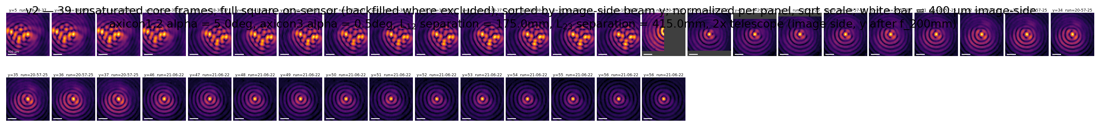

In [5]:
# --- v2 gallery: fills-the-square filter + arbitrary (y, run) exclusions -----
# The ±994 µm crop is NaN wherever it ran off the sensor, so "central lobe
# cut off" == any NaN in the thumbnail. Saturated core frames are dropped
# here too (everything downstream of v2 is photometric). On top of that, v2_filters_additional
# drops arbitrary (y, run) frames — applied to the frame list BEFORE the grid
# is laid out, so panels pack with no holes in the tiling. If an exclusion
# empties a y value entirely, BACKFILL_EMPTY_Y pulls the least-clipped
# remaining frame at that y back in (fill-the-square relaxed for that y only)
# so the y ladder stays complete. filled-and-kept selection for downstream
# fits: keep_v2 / order_v2.
v2_filters_additional = []
BACKFILL_EMPTY_Y = True

filled_mask = ~np.isnan(core_thumbs).any(axis=(1, 2))
excl_mask = np.zeros(len(ct_ys), bool)
for f in v2_filters_additional:
    excl_mask |= np.isclose(ct_ys, f["y"]) & (ct_runs == f["run"])
keep_v2 = filled_mask & ~ct_sat & ~excl_mask

if BACKFILL_EMPTY_Y:
    frac_on = 1 - np.isnan(core_thumbs).mean(axis=(1, 2))
    for y in np.unique(ct_ys):
        at_y = ct_ys == y
        if (keep_v2 & at_y).any():
            continue
        cand = np.where(at_y & ~excl_mask & ~ct_sat)[0]
        if len(cand) == 0:
            print(f"y={y:g}: every frame excluded — gap in the y ladder")
            continue
        pick = cand[np.argmax(frac_on[cand])]
        keep_v2[pick] = True
        print(f"y={y:g}: backfilled with edge-clipped {str(ct_frames[pick])} "
              f"({frac_on[pick]:.0%} on-sensor)")

order_v2 = order[keep_v2[order]]
print(f"v2: {int(keep_v2.sum())} frames = {int(filled_mask.sum())} filled "
      f"- {int((filled_mask & ct_sat).sum())} saturated "
      f"- {int((filled_mask & ~ct_sat & excl_mask).sum())} excluded "
      f"+ {int((keep_v2 & ~filled_mask).sum())} backfilled")

n_rows_v2 = int(np.ceil(len(order_v2) / N_COLS_CF))
fig, axes = plt.subplots(n_rows_v2, N_COLS_CF,
                         figsize=(0.95 * N_COLS_CF, 1.08 * n_rows_v2),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, i in zip(np.ravel(axes), order_v2):
    t = core_thumbs[i]
    ax.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
              vmin=0, vmax=1, interpolation="nearest")
    # scale bar: 400 um image-side = 29.0 thumb px (13.8 um/px)
    ax.plot([5, 5 + 400 / 13.8], [137, 137], color="w", lw=1.0,
            solid_capstyle="butt")
    ax.set_title(f"y={ct_ys[i]:g}  run={str(ct_runs[i])[-8:]}", fontsize=4.5,
                 pad=1.5)
fig.subplots_adjust(top=0.98, hspace=0.25, wspace=0.05)
fig.suptitle(f"v2 — {len(order_v2)} unsaturated core frames, full square "
             "on-sensor (backfilled where excluded), sorted by image-side "
             "beam y; normalized per panel, sqrt scale; white bar = 400 µm "
             "image-side.\n" + OPTIC_TITLE,
             y=0.999, fontsize=13)
for ax in np.ravel(axes)[:1]:
    ax.text(5, 133, "400 µm", color="w", fontsize=3.5, va="bottom")
save_fig("core_frame_gallery_v2")
plt.close(fig)
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_frame_gallery_v2.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

In [6]:
# --- 1D J0^2 fits per v2 frame: X lineout, Z lineout, radial profile ---------
# Preprocessing (input: the v2-selected thumbnails, 13.8 um/px):
#   1. per frame, core pixel = argmax of the thumbnail
#   2. X lineout = the row through the core; Z lineout = the column; offsets
#      in image-side um from the core pixel (camera row -> machine Z,
#      col -> X, both flipped 180 deg — symmetric profiles, flip irrelevant)
#   3. radial profile = azimuthal mean in 13.8 um bins about the sub-pixel
#      centroid of the 5x5 block at the core
#   4. each of the three fits A*J0^2(k*(u-u0)) + C by least squares
#      (scipy curve_fit) over |u| <= 900 um (2x the direct-measurement
#      window); u0 fixed at 0 for the radial fit
#   5. the ideal for image space is KR_IDEAL / M_TEL (transverse features
#      2x wider); k bounds 0.2-4x of that, u0 bounds scaled 2x
#   6. no cache — recomputed from the thumbnails in seconds
import sys
from scipy.optimize import curve_fit
from scipy.special import j0

sys.path.insert(0, str(REPO.parent / "bessel-beam-webapp"))
from simulator.qdht_axicon import axicon_kr

KR_IDEAL = axicon_kr(ALPHA3_DEG)          # rad/m, ideal axicon-3 cone (object side)
KR_IDEAL_TEL = KR_IDEAL / M_TEL           # rad/m, image side through the 2x telescope
UM_PER_PX = 13.8
FIT_HALF_UM = 900.0


def j0sq_c(u_um, A, k, u0_um, C):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + C


def fit_profile(u_um, I, free_center=True):
    ok = np.isfinite(I) & (np.abs(u_um) <= FIT_HALF_UM)
    p0 = [np.nanmax(I[ok]), KR_IDEAL_TEL, 0.0, 0.0]
    lo = [0, 0.2 * KR_IDEAL_TEL, -70.0, -np.inf]
    hi = [np.inf, 4.0 * KR_IDEAL_TEL, 70.0, np.inf]
    if not free_center:
        lo[2], hi[2] = -1e-9, 1e-9
    popt, pcov, infodict, mesg, ier = curve_fit(j0sq_c, u_um[ok], I[ok], p0=p0, bounds=(lo, hi), full_output=True)
    perr = np.sqrt(np.diag(pcov))
    resid = I[ok] - j0sq_c(u_um[ok], *popt)
    return popt, float(np.sqrt(np.mean(resid ** 2)) / popt[0]), perr


fits1d = []
for i in order_v2:
    t = core_thumbs[i]
    py, px = np.unravel_index(np.nanargmax(t), t.shape)
    x_u = (np.arange(t.shape[1]) - px) * UM_PER_PX
    z_u = (np.arange(t.shape[0]) - py) * UM_PER_PX
    # sub-pixel centroid for the radial profile
    w = np.nan_to_num(t[max(py-2, 0):py+3, max(px-2, 0):px+3])
    wy, wx = np.mgrid[max(py-2, 0):py+3, max(px-2, 0):px+3]
    cy, cx = (w*wy).sum()/w.sum(), (w*wx).sum()/w.sum()
    yy, xx = np.mgrid[0:t.shape[0], 0:t.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * UM_PER_PX
    fin = np.isfinite(t)
    b = (r_um[fin] / UM_PER_PX).astype(int)
    prof = (np.bincount(b, weights=t[fin]) /
            np.maximum(np.bincount(b), 1))
    r_cent = (np.arange(len(prof)) + 0.5) * UM_PER_PX
    px_fit, rms_x, perr_x = fit_profile(x_u, t[py, :])
    pz_fit, rms_z, perr_z = fit_profile(z_u, t[:, px])
    pr_fit, rms_r, perr_r = fit_profile(r_cent, prof, free_center=False)
    fits1d.append(dict(i=i, y=float(ct_ys[i]), run=str(ct_runs[i]),
                       x_u=x_u, z_u=z_u, Ix=t[py, :], Iz=t[:, px],
                       r=r_cent, Ir=prof,
                       px=px_fit, pz=pz_fit, pr=pr_fit,
                       rms=(rms_x, rms_z, rms_r),
                       err=(perr_x, perr_z, perr_r)))
kx = np.array([f["px"][1] for f in fits1d])
kz = np.array([f["pz"][1] for f in fits1d])
kr_ = np.array([f["pr"][1] for f in fits1d])
print(f"{len(fits1d)} frames fit | image-side ideal kr3/M = {KR_IDEAL_TEL:.4g} rad/m")
for nm, k in (("x", kx), ("z", kz), ("radial", kr_)):
    print(f"  k_{nm}: median {np.median(k):.4g} rad/m "
          f"({np.median(k)/KR_IDEAL_TEL - 1:+.1%} vs ideal/M), "
          f"IQR {np.percentile(k, 25)/KR_IDEAL_TEL - 1:+.1%} … "
          f"{np.percentile(k, 75)/KR_IDEAL_TEL - 1:+.1%}")

39 frames fit | image-side ideal kr3/M = 1.934e+04 rad/m
  k_x: median 1.828e+04 rad/m (-5.5% vs ideal/M), IQR -7.8% … -2.1%
  k_z: median 1.716e+04 rad/m (-11.3% vs ideal/M), IQR -26.9% … -8.3%
  k_radial: median 1.728e+04 rad/m (-10.7% vs ideal/M), IQR -11.5% … -7.2%


saved images/telescope_central_bessel_lobe_2026_08_06/core_1d_profiles_gallery.png


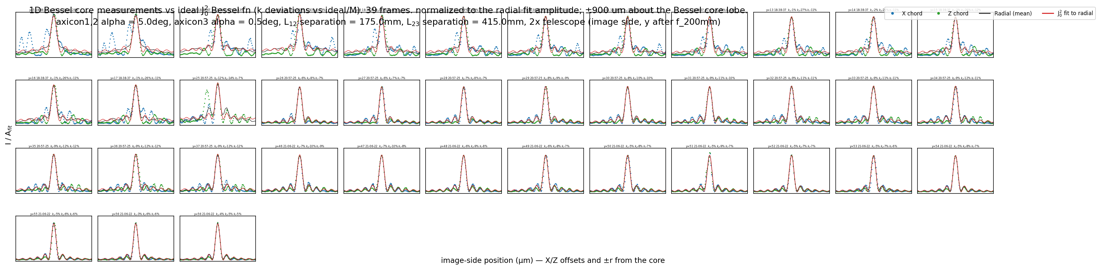

In [7]:
# --- per-frame 1D comparison gallery -----------------------------------------
N_COLS_1D = 12
n_rows_1d = int(np.ceil(len(fits1d) / N_COLS_1D))
u_fine = np.linspace(-FIT_HALF_UM, FIT_HALF_UM, 400)
fig, axes = plt.subplots(n_rows_1d, N_COLS_1D,
                         figsize=(1.9 * N_COLS_1D, 1.35 * n_rows_1d),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, f in zip(np.ravel(axes), fits1d):
    ax.set_axis_on()
    ax.set_xticks([]); ax.set_yticks([])
    A = f["pr"][0]
    ax.plot(f["x_u"], f["Ix"] / A, ".", ms=1.2, color="tab:blue")

    ax.plot(f["z_u"], f["Iz"] / A, ".", ms=1.2, color="tab:green")
    ax.plot(f["r"], f["Ir"] / A, "-", color="0.2", lw=0.7)
    ax.plot(-f["r"], f["Ir"] / A, "-", color="0.2", lw=0.7)
    ax.plot(u_fine, j0sq_c(u_fine, *f["pr"]) / A, "-", color="tab:red",
            lw=0.8, alpha=0.85)
    ax.set_xlim(-FIT_HALF_UM, FIT_HALF_UM)
    ax.set_ylim(-0.05, 1.2)
    ax.set_title(f"y={f['y']:g} {f['run'][-8:]}  "
                 f"$k_x${f['px'][1]/KR_IDEAL_TEL-1:+.0%} "
                 f"$k_z${f['pz'][1]/KR_IDEAL_TEL-1:+.0%} "
                 f"$k_r${f['pr'][1]/KR_IDEAL_TEL-1:+.0%}", fontsize=4, pad=1.5)
h = [plt.Line2D([], [], marker=".", ls="", color="tab:blue", label="X chord"),
     plt.Line2D([], [], marker=".", ls="", color="tab:green", label="Z chord"),
     plt.Line2D([], [], color="0.2", label="Radial (mean)"),
     plt.Line2D([], [], color="tab:red", label="J$_0^2$ fit to radial")]
fig.legend(handles=h, loc="upper right", fontsize=8, ncol=4,
           bbox_to_anchor=(0.995, 0.999))
fig.supxlabel("image-side position (µm) — X/Z offsets and ±r from the core",
              fontsize=11, y=0.0015)
fig.supylabel("I / A$_{fit}$", fontsize=11, x=0.002)
fig.subplots_adjust(top=0.97, bottom=0.012, left=0.012, hspace=0.5,
                    wspace=0.08)
fig.suptitle(f"1D Bessel core measurements vs ideal J$_0^2$ Bessel fn (k deviations vs ideal/M). {len(fits1d)} frames. "
             "normalized to the radial fit amplitude; ±900 um about the Bessel core lobe.\n" + OPTIC_TITLE,
             y=0.999, fontsize=13, x=0.35)
save_fig("core_1d_profiles_gallery")
plt.close(fig)
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_1d_profiles_gallery.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

saved images/telescope_central_bessel_lobe_2026_08_06/core_1d_fit_k_vs_y.png


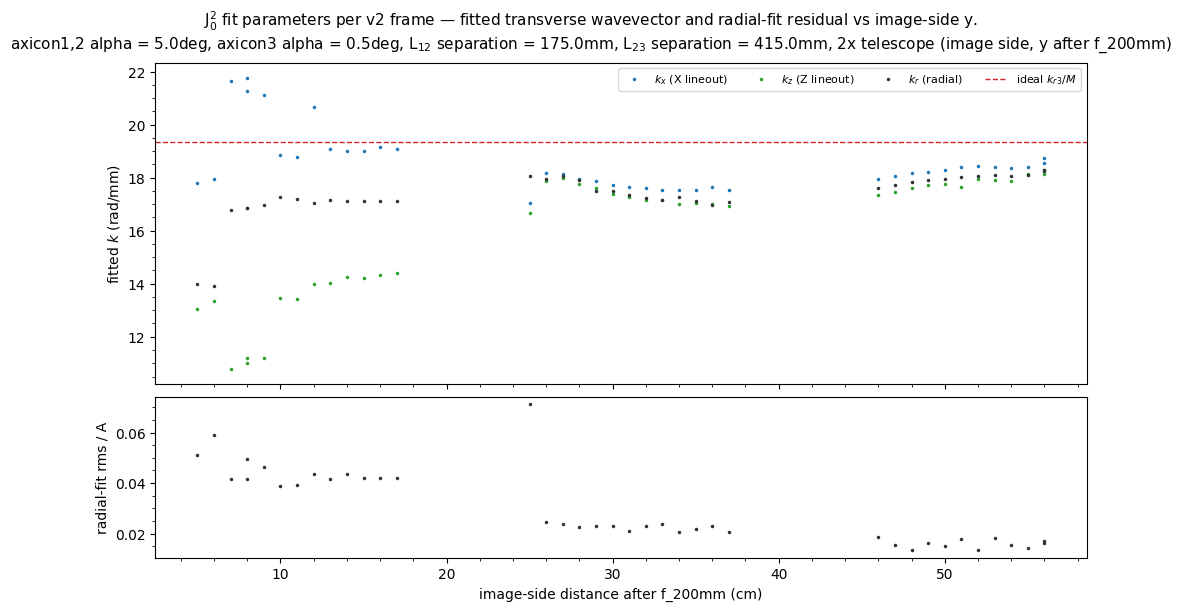

In [8]:
# --- fitted k vs y summary ---------------------------------------------------
ys_f = np.array([f["y"] for f in fits1d])
rms_r_f = np.array([f["rms"][2] for f in fits1d])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               height_ratios=[2, 1], layout="constrained")
ax1.plot(ys_f, kx / 1e3, ".", ms=3, color="tab:blue", label="$k_x$ (X lineout)")
ax1.plot(ys_f, kz / 1e3, ".", ms=3, color="tab:green", label="$k_z$ (Z lineout)")
ax1.plot(ys_f, kr_ / 1e3, ".", ms=3, color="0.2", label="$k_r$ (radial)")
ax1.axhline(KR_IDEAL_TEL / 1e3, color="tab:red", ls="--", lw=1,
            label="ideal $k_{r3}/M$")
ax1.set_ylabel("fitted $k$ (rad/mm)")
ax1.legend(fontsize=8, ncol=4)
ax1.minorticks_on()
ax2.plot(ys_f, rms_r_f, ".", ms=3, color="0.2")
ax2.set_ylabel("radial-fit rms / A")
ax2.set_xlabel("image-side distance after f_200mm (cm)")
ax2.minorticks_on()
fig.suptitle("J$_0^2$ fit parameters per v2 frame — fitted transverse "
             "wavevector and radial-fit residual vs image-side y.\n" + OPTIC_TITLE, fontsize=11)
save_fig("core_1d_fit_k_vs_y")
plt.show()

y=20: no v2 frame at this y — row skipped
y=25: no fit with rms/A <= 0.06 — picking from all 1 candidates
y=40: no v2 frame at this y — row skipped
y=45: no v2 frame at this y — row skipped


saved images/telescope_central_bessel_lobe_2026_08_06/core_frame_gallery_v3.png


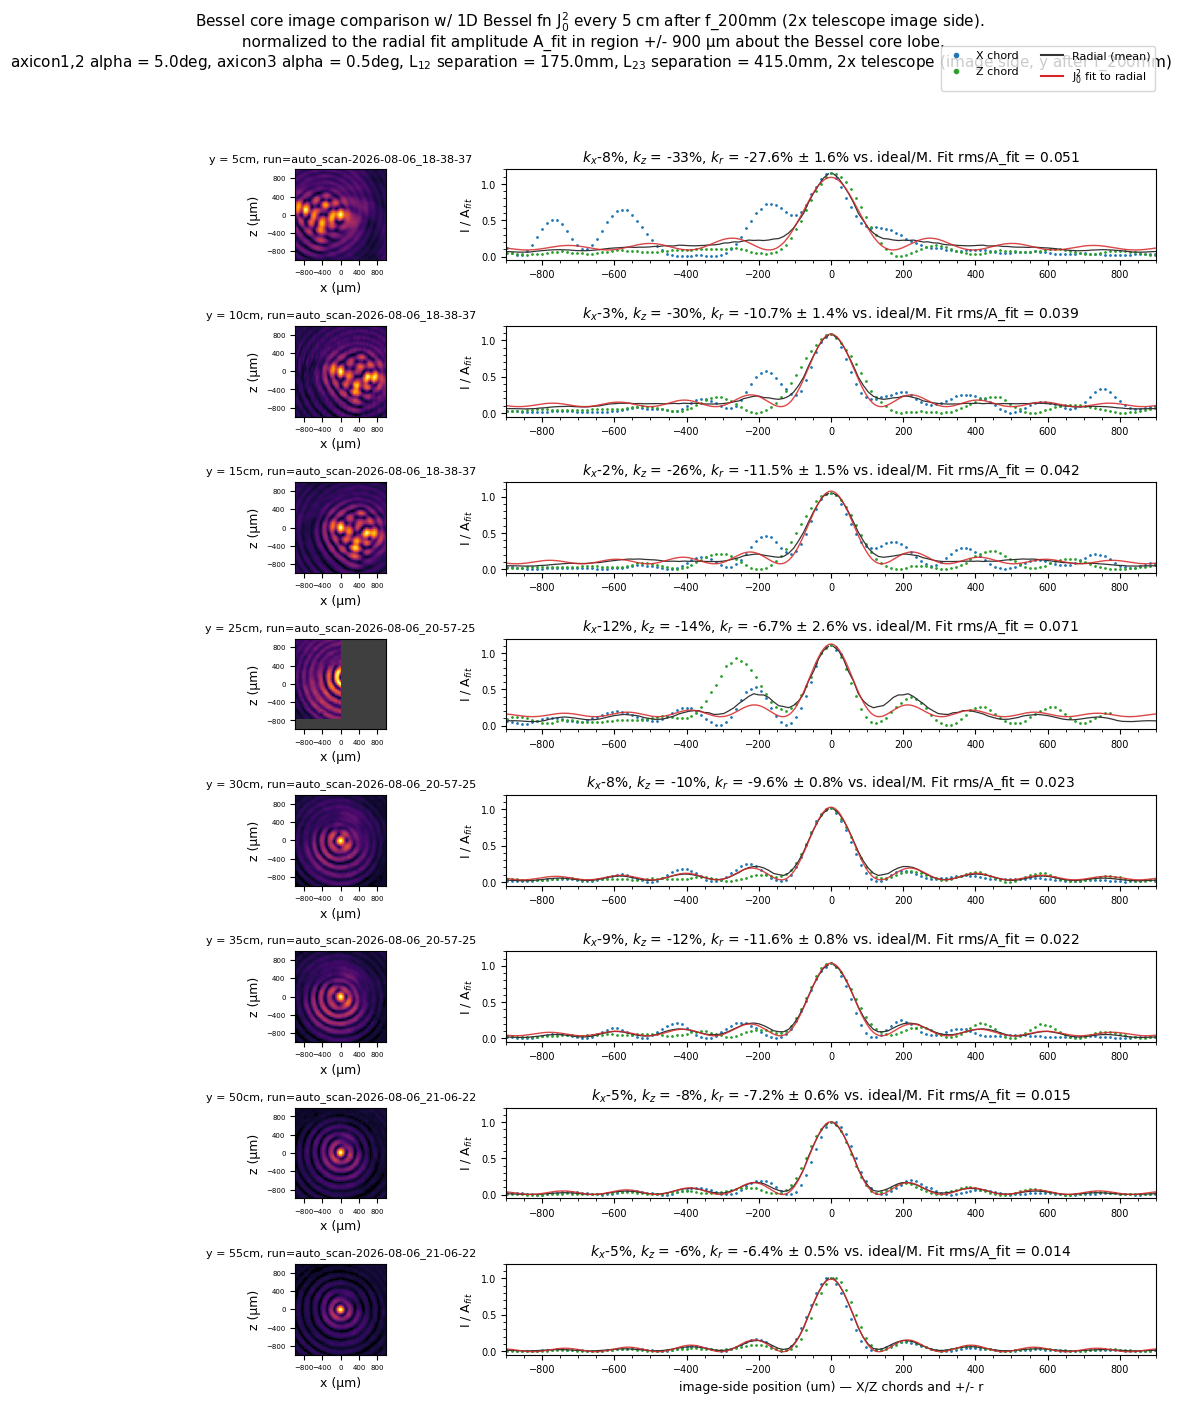

In [9]:
# --- v3 gallery: image + 1D comparison, one frame every 5 cm -----------------
# Selection: at each y in 5, 10, ..., 55 cm (5-cm spacing — the covered
# image-side span is only 51 cm), the brightest v2 frame (largest radial-fit
# amplitude A) among clean fits — rms_r <= 0.06, the fit_ok cut; a halo-arc
# frame fit poorly can carry an inflated A, so rank only the clean ones and
# fall back to every candidate if a y has none. One row per y: thumbnail on
# the left, X/Z chords + radial profile + J0^2 fit on the right.
Y_TARGETS = np.arange(5, 56, 5)
RMS_OK = 0.06

picks = []
for y0 in Y_TARGETS:
    cands = [f for f in fits1d if np.isclose(f["y"], y0)]
    if not cands:
        print(f"y={y0}: no v2 frame at this y — row skipped")
        continue
    clean = [f for f in cands if f["rms"][2] <= RMS_OK]
    if not clean:
        print(f"y={y0}: no fit with rms/A <= {RMS_OK} — picking from all "
              f"{len(cands)} candidates")
    picks.append(max(clean or cands, key=lambda f: f["pr"][0]))

u_fine = np.linspace(-FIT_HALF_UM, FIT_HALF_UM, 500)
fig, axes = plt.subplots(len(picks), 2, figsize=(10, 1.75 * len(picks)),
                         squeeze=False, width_ratios=[1, 2.1], sharex=False, sharey=False)
for (ax_im, ax_pr), f in zip(axes, picks):
    t = core_thumbs[f["i"]]
    ax_im.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
                 vmin=0, vmax=1, interpolation="nearest",
                 extent=[-994, 994, -994, 994])
    ax_im.set_xticks([-800, -400, 0, 400, 800])
    ax_im.set_yticks([-800, -400, 0, 400, 800])
    ax_im.tick_params(labelsize=5)
    ax_im.set_xlabel(f"x (µm)", fontsize=9)
    ax_im.set_ylabel(f"z (µm)", fontsize=9)
    ax_im.set_title(f"y = {f['y']:g}cm, run={f['run']}", fontsize=8)

    A = f["pr"][0]
    ax_pr.set_ylabel("I / A$_{fit}$", fontsize=9)
    ax_pr.plot(f["x_u"], f["Ix"] / A, ".", ms=2, color="tab:blue")
    ax_pr.plot(f["z_u"], f["Iz"] / A, ".", ms=2, color="tab:green")
    ax_pr.plot(f["r"], f["Ir"] / A, "-", color="0.2", lw=0.9)
    ax_pr.plot(-f["r"], f["Ir"] / A, "-", color="0.2", lw=0.9)
    ax_pr.plot(u_fine, j0sq_c(u_fine, *f["pr"]) / A, "-", color="tab:red",
               lw=1.0, alpha=0.85)
    ax_pr.set_xlim(-FIT_HALF_UM, FIT_HALF_UM)
    ax_pr.set_ylim(-0.05, 1.2)
    ax_pr.tick_params(labelsize=7)
    ax_pr.minorticks_on()
    kdev = f["pr"][1] / KR_IDEAL_TEL - 1
    kerr = f["err"][2][1] / KR_IDEAL_TEL
    ax_pr.set_title(
                    f"$k_x${f['px'][1]/KR_IDEAL_TEL-1:+.0%}, "
                    f"$k_z$ = {f['pz'][1]/KR_IDEAL_TEL-1:+.0%}, "
                    f"$k_r$ = {kdev:+.1%} ± {kerr:.1%} vs. ideal/M. "
                    f"Fit rms/A_fit = {f['rms'][2]:.3f}", fontsize=10)

axes[-1][1].set_xlabel("image-side position (um) — X/Z chords and +/- r", fontsize=9)
h = [plt.Line2D([], [], marker=".", ls="", color="tab:blue", label="X chord"),
     plt.Line2D([], [], marker=".", ls="", color="tab:green", label="Z chord"),
     plt.Line2D([], [], color="0.2", label="Radial (mean)"),
     plt.Line2D([], [], color="tab:red", label="J$_0^2$ fit to radial")]
fig.legend(handles=h, loc="upper right", fontsize=8, ncol=2,
           bbox_to_anchor=(0.99, 0.9765))
fig.suptitle(f"Bessel core image comparison w/ 1D Bessel fn J$_0^2$ every 5 cm after f_200mm (2x telescope image side). \n"
             " normalized to the radial fit amplitude A_fit in region +/- 900 µm about the Bessel core lobe." + "\n" + OPTIC_TITLE,
             fontsize=11, x=0.42, y=0.999)
plt.tight_layout(rect=[0, 0, 1, 0.966])
save_fig("core_frame_gallery_v3")
plt.show()

saved images/telescope_central_bessel_lobe_2026_08_06/core_fit_kr_vs_y.png


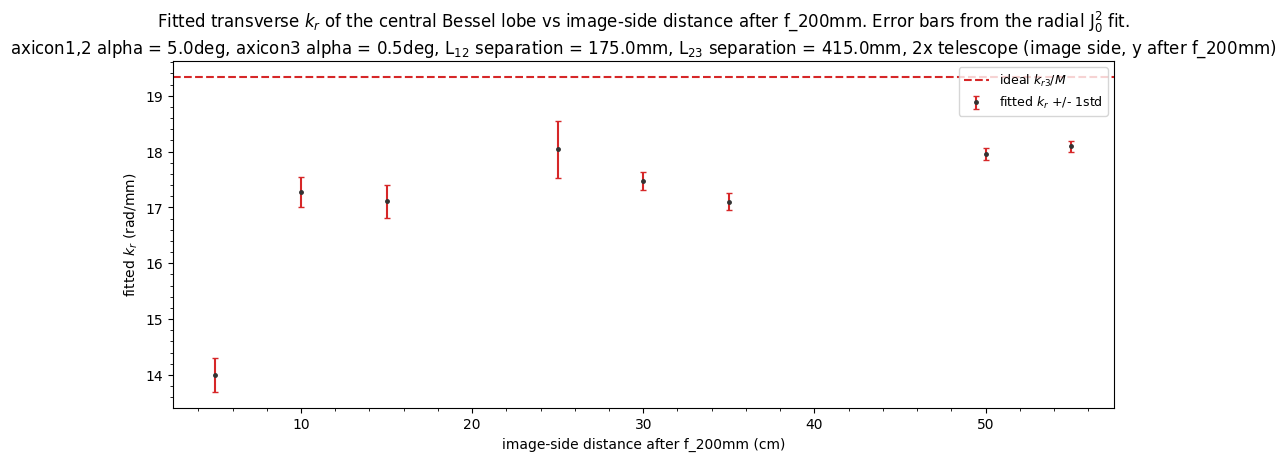

In [10]:
# Summary plot: central lobe fitted kr vs image-side distance, with error bars
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.errorbar([f["y"] for f in picks], [f["pr"][1] / 1e3 for f in picks],
            yerr=[f["err"][2][1] / 1e3 for f in picks], fmt=".", ms=5,
            color="0.2", ecolor="tab:red", elinewidth=1.5, capsize=2, label="fitted $k_r$ +/- 1std")
ax.axhline(KR_IDEAL_TEL / 1e3, color="tab:red", ls="--", lw=1.5, label="ideal $k_{r3}/M$")
ax.set_xlabel("image-side distance after f_200mm (cm)")
ax.set_ylabel("fitted $k_r$ (rad/mm)")
ax.set_title("Fitted transverse $k_r$ of the central Bessel lobe vs image-side distance after f_200mm. Error bars from the radial J$_0^2$ fit.\n" + OPTIC_TITLE)
ax.legend(fontsize=9, loc="upper right")
ax.minorticks_on()
save_fig("core_fit_kr_vs_y")

saved images/telescope_central_bessel_lobe_2026_08_06/core_fit_kx_vs_y.png


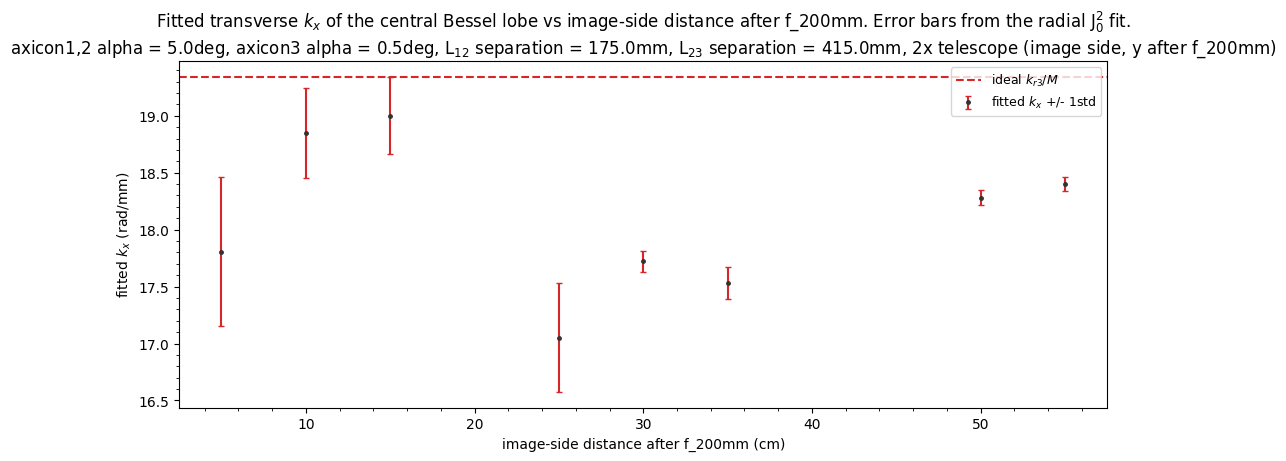

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.errorbar([f["y"] for f in picks], [f["px"][1] / 1e3 for f in picks],
            yerr=[f["err"][0][1] / 1e3 for f in picks], fmt=".", ms=5,
            color="0.2", ecolor="tab:red", elinewidth=1.5, capsize=2, label="fitted $k_x$ +/- 1std")
ax.axhline(KR_IDEAL_TEL / 1e3, color="tab:red", ls="--", lw=1.5, label="ideal $k_{r3}/M$")
ax.set_xlabel("image-side distance after f_200mm (cm)")
ax.set_ylabel("fitted $k_x$ (rad/mm)")
ax.set_title("Fitted transverse $k_x$ of the central Bessel lobe vs image-side distance after f_200mm. Error bars from the radial J$_0^2$ fit.\n" + OPTIC_TITLE)
ax.legend(fontsize=9, loc="upper right")
ax.minorticks_on()
save_fig("core_fit_kx_vs_y")

39 frames; fit-amplitude peak 0.2844 counts/µs at y = 56 cm


saved images/telescope_central_bessel_lobe_2026_08_06/axial_profile_from_fits.png


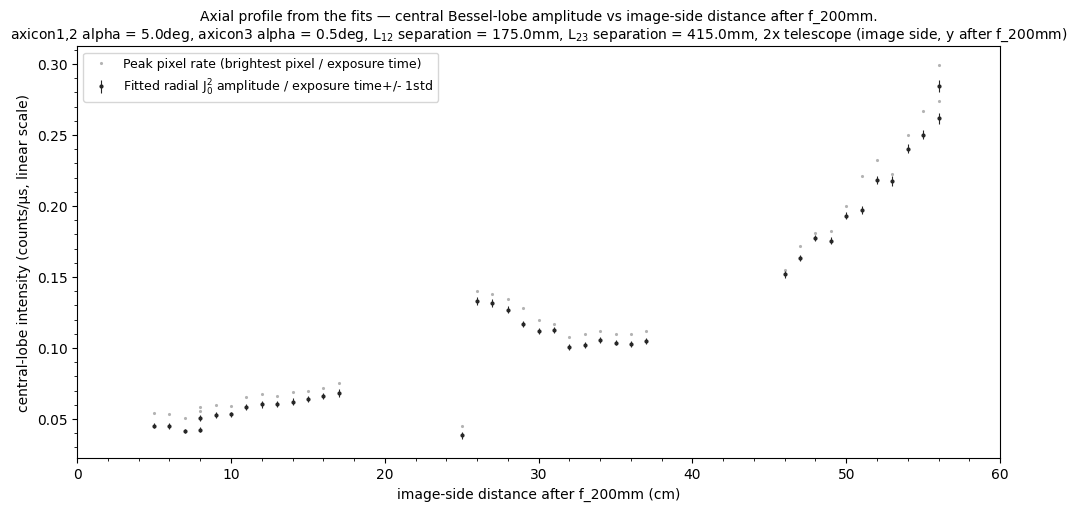

In [12]:
# --- axial profile from the fits: central-lobe amplitude vs image-side y -----
# Same construction as the aug5 notebook: fitted radial J0^2 amplitude / that
# frame's calibrated exposure -> counts/us, 1-sigma error bars from the fit
# covariance; gray dots the same frames' raw peak-pixel rate. NO QDHT overlay:
# the model lives in object space and the image<->object conjugate mapping is
# not recorded — see telescope_vs_axicon3_comparison_2026_08_06 for the
# side-by-side against the direct measurement.
exp_lookup = {(r["run"], r["frame"]): r["exposure_us"] for r in core_rows}
rate_lookup = {(r["run"], r["frame"]): r["rate_c_per_us"] for r in core_rows}

ys_a, A_rate, A_err, pk_rate = [], [], [], []
for f in fits1d:
    key = (f["run"], str(ct_frames[f["i"]]))
    T = exp_lookup.get(key)
    if T is None:
        print(f"MISSING manifest row for {key} — skipped")
        continue
    ys_a.append(f["y"])
    A_rate.append(f["pr"][0] / T)
    A_err.append(f["err"][2][0] / T)
    pk_rate.append(rate_lookup[key])
ys_a, A_rate = np.array(ys_a), np.array(A_rate)
A_err, pk_rate = np.array(A_err), np.array(pk_rate)
print(f"{len(ys_a)} frames; fit-amplitude peak {A_rate.max():.4f} counts/µs "
      f"at y = {ys_a[np.argmax(A_rate)]:g} cm")

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(ys_a, pk_rate, ".", ms=2.5, color="0.7",
        label="Peak pixel rate (brightest pixel / exposure time)")
ax.errorbar(ys_a, A_rate, yerr=A_err, fmt=".", ms=4, color="0.15",
            elinewidth=0.8, label="Fitted radial J$_0^2$ amplitude / exposure time"
            "+/- 1std")
ax.set_xlim(0, 60)
ax.set_xlabel("image-side distance after f_200mm (cm)")
ax.set_ylabel("central-lobe intensity (counts/µs, linear scale)")
ax.minorticks_on()
ax.legend(fontsize=9)
ax.set_title("Axial profile from the fits — central Bessel-lobe amplitude vs "
             "image-side distance after f_200mm.\n" + OPTIC_TITLE, fontsize=10)
save_fig("axial_profile_from_fits")
plt.show()